Author: Jule Grimm, Johanna Rissbacher <br>
Date: 21/10

## Project BERN02

In [4]:
import pandas as pd
import numpy as np
import sklearn as sk
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SequentialFeatureSelector
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.metrics import accuracy_score, r2_score
import matplotlib.pyplot as plt

In [5]:
# load data
stress_data = pd.read_csv('data/Stress_wrangled.csv')

#### Data preparation

In [6]:
stress_data.rename(columns={'stresstype': 'target'}, inplace=True)

# Different target codes
target_order = {"Eustress (Positive Stress) - Stress that motivates and enhances performance.": 0, "No Stress - Currently experiencing minimal to no stress.": 1, "Distress (Negative Stress) - Stress that causes anxiety and impairs well-being.": 2}
stress_data["target_ordered"] = stress_data["target"].map(target_order)

# Split in male and female
female = stress_data[stress_data['Gender'] == 1]
male = stress_data[stress_data['Gender'] == 0]

X_f = female.drop(columns=['Gender', 'target', 'target_ordered'])
y_f = female['target_ordered']

X_m = male.drop(columns=['Gender', 'target', 'target_ordered'])
y_m = male['target_ordered']

# split data
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_f, y_f, test_size=0.2, random_state=42)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_m, y_m, test_size=0.2, random_state=42)

# define model
multi_reg_f = LogisticRegression(solver='newton-cg', max_iter=1000)
multi_reg_m = LogisticRegression(solver='newton-cg', max_iter=1000)

#### Hyperparameter tuning for upper boundary

If we run the model with `k_features='best'`, the number of selected features is still very high (ca. 17 features). <br>
However, our goal is to find a simple model with a high complexity. That's why we definde `k_features=(1,upper)` and do a hyperparameter tuning for the upper boundry. We vary the upper boundary in the range of 1 to 10 and calculate the accuarcy of the model when testing it on the unseen test data.

In [7]:
# Female
if 0:
    accs = [[],[],[]]
    for upper in range(1, 11):
        #-------------------------------
        # Feature selection (mlxtend)
        #-------------------------------
        # forward
        sfs_f_f = SFS(multi_reg_f, k_features=(1, upper), forward=True)
        sfs_f_f = sfs_f_f.fit(X_train_f, y_train_f)
        results_f_f = pd.DataFrame.from_dict(sfs_f_f.get_metric_dict()).T
        features_ff = list(sfs_f_f.k_feature_names_)

        # backward
        sfs_f_b = SFS(multi_reg_f, k_features=(1, upper), forward=False)
        sfs_f_b = sfs_f_b.fit(X_train_f, y_train_f)
        results_f_b = pd.DataFrame.from_dict(sfs_f_b.get_metric_dict()).T
        features_fb = list(sfs_f_b.k_feature_names_)

        # stepwise selection (floating)
        sfs_f_s = SFS(multi_reg_f, k_features=(1, upper), forward=True, floating=True)
        sfs_f_s = sfs_f_s.fit(X_train_f, y_train_f)
        results_f_s = pd.DataFrame.from_dict(sfs_f_s.get_metric_dict()).T
        features_fs = list(sfs_f_s.k_feature_names_)
        
        #-------------------------------
        # Model evaluation
        #-------------------------------
        model_ff = LogisticRegression(solver='newton-cg', max_iter=1000)
        model_ff.fit(X_train_f[features_ff], y_train_f)
        pred_ff = model_ff.predict(X_test_f[features_ff])
        acc_ff = accuracy_score(y_test_f, pred_ff)

        model_fb = LogisticRegression(solver='newton-cg', max_iter=1000)
        model_fb.fit(X_train_f[features_fb], y_train_f)
        pred_fb = model_fb.predict(X_test_f[features_fb])
        acc_fb = accuracy_score(y_test_f, pred_fb)

        model_fs = LogisticRegression(solver='newton-cg', max_iter=1000)
        model_fs.fit(X_train_f[features_fs], y_train_f)
        pred_fs = model_fs.predict(X_test_f[features_fs])
        acc_fs = accuracy_score(y_test_f, pred_fs)

        accs[0].append(np.round(acc_ff, 4))
        accs[1].append(np.round(acc_fb, 4))
        accs[2].append(np.round(acc_fs, 4))
        # check accuarcy of female model
        # print(f'female forward: {np.round(acc_ff, 4)}, backward: {np.round(acc_fb, 4)}, stepwise: {np.round(acc_fs, 4)}')

    # accuracy score for every number of features and method
    accs = np.array(accs)
    df_accs = pd.DataFrame({'forward' : accs[0], 'backward': accs[1], 'floating': accs[2]})
    df_accs.to_csv('female_accuracies.csv')

In [8]:
# Male
if 0: 
    accs = [[],[],[]]
    for upper in range(1, 11):
        #-------------------------------
        # Feature selection (mlxtend)
        #-------------------------------
        # forward
        sfs_m_f = SFS(multi_reg_m, k_features=(1, upper), forward=True)
        sfs_m_f = sfs_m_f.fit(X_train_m, y_train_m)
        results_m_f = pd.DataFrame.from_dict(sfs_m_f.get_metric_dict()).T
        features_mf = list(sfs_m_f.k_feature_names_)

        # backward
        sfs_m_b = SFS(multi_reg_m, k_features=(1, upper), forward=False)
        sfs_m_b = sfs_m_b.fit(X_train_m, y_train_m)
        results_m_b = pd.DataFrame.from_dict(sfs_m_b.get_metric_dict()).T
        features_mb = list(sfs_m_b.k_feature_names_)

        # stepwise selection (floating)
        sfs_m_s = SFS(multi_reg_m, k_features=(1, upper), forward=True, floating=True)
        sfs_m_s = sfs_m_s.fit(X_train_m, y_train_m)
        results_m_s = pd.DataFrame.from_dict(sfs_m_s.get_metric_dict()).T
        features_ms = list(sfs_m_s.k_feature_names_)
        
        #-------------------------------
        # Model evaluation
        #-------------------------------
        model_mf = LogisticRegression(solver='newton-cg', max_iter=1000)
        model_mf.fit(X_train_m[features_mf], y_train_m)
        pred_mf = model_mf.predict(X_test_m[features_mf])
        acc_mf = accuracy_score(y_test_m, pred_mf)

        model_mb = LogisticRegression(solver='newton-cg', max_iter=1000)
        model_mb.fit(X_train_m[features_mb], y_train_m)
        pred_mb = model_mb.predict(X_test_m[features_mb])
        acc_mb = accuracy_score(y_test_m, pred_mb)

        model_ms = LogisticRegression(solver='newton-cg', max_iter=1000)
        model_ms.fit(X_train_m[features_ms], y_train_m)
        pred_ms = model_ms.predict(X_test_m[features_ms])
        acc_ms = accuracy_score(y_test_m, pred_ms)

        accs[0].append(np.round(acc_mf, 4))
        accs[1].append(np.round(acc_mb, 4))
        accs[2].append(np.round(acc_ms, 4))
        # # check accuarcy of male model
        # print(f'male forward: {np.round(acc_mf, 4)}, backward: {np.round(acc_mb, 4)}, stepwise: {np.round(acc_ms, 4)}')
    
    # accuracy score for every number of features and method
    accs = np.array(accs)
    df_accs = pd.DataFrame({'forward' : accs[0], 'backward': accs[1], 'floating': accs[2]})
    df_accs.to_csv('male_accuracies.csv')

In [9]:
# read dataframe of accuracies
df_accs_f = pd.read_csv('female_accuracies.csv', index_col=0)
df_accs_m = pd.read_csv('male_accuracies.csv', index_col=0)

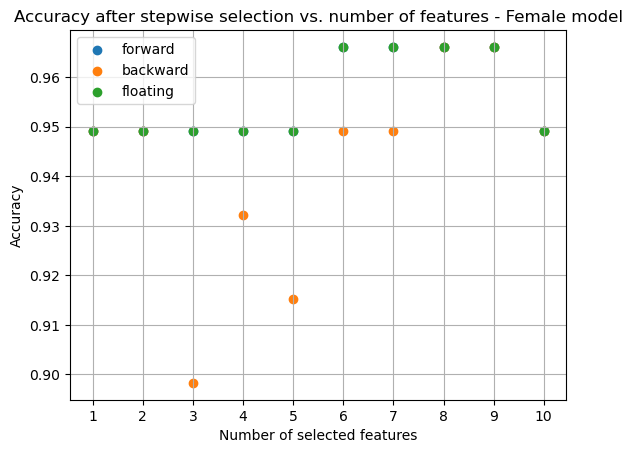

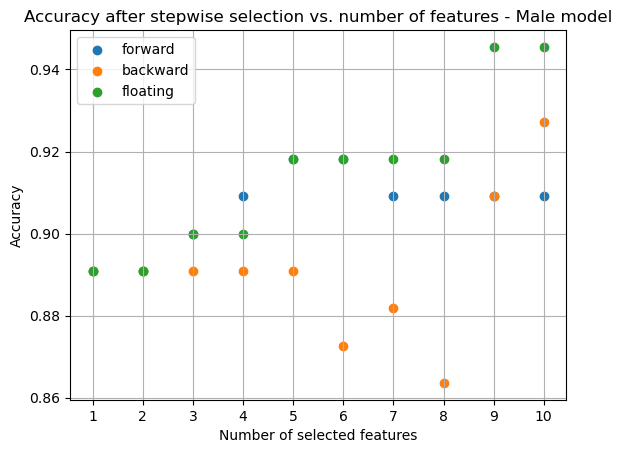

In [10]:
# plot the number of selected features against the accuarcy of the model 
for col in df_accs_f.columns:
    plt.scatter(df_accs_f.index + 1, df_accs_f[col], label=col)
plt.xlabel("Number of selected features")
plt.ylabel("Accuracy")
plt.title("Accuracy after stepwise selection vs. number of features - Female model")
plt.grid()
plt.legend()
plt.xticks(np.arange(1, len(df_accs_f.index) + 1, 1))
plt.show()

for col in df_accs_m.columns:
    plt.scatter(df_accs_m.index + 1, df_accs_m[col], label=col)
plt.xlabel("Number of selected features")
plt.ylabel("Accuracy")
plt.title("Accuracy after stepwise selection vs. number of features - Male model")
plt.grid()
plt.legend()
plt.xticks(np.arange(1, len(df_accs_m.index) + 1, 1))
plt.show()

##### Selected number of features
Female: optimum of 6 features <br>
Male: optimum of 5 features

For both the female and male model, the number of features when performing a forward feature selection and backward feature selection was the same and produced the same model accuracy. <br>
We now want to check if the features selected by forward/floating selection are the same in the corresponding model.

In [11]:
## female: define model with optimum number of features
# run with forward feature selection
sfs_f_f = SFS(multi_reg_f, k_features=(1, 6), forward=True)
sfs_f_f = sfs_f_f.fit(X_train_f, y_train_f)
features_ff = list(sfs_f_f.k_feature_names_)

# stepwise selection (floating)
sfs_f_s = SFS(multi_reg_f, k_features=(1, 6), forward=True, floating=True)
sfs_f_s = sfs_f_s.fit(X_train_f, y_train_f)
features_fs = list(sfs_f_s.k_feature_names_)

# check if both methods selected the same features
print(f'Female: forward selected features: {features_ff}\n floating selected features: {features_fs}')

Female: forward selected features: ['stress', 'anxiety', 'sadness', 'headaches', 'weight', 'work_env']
 floating selected features: ['stress', 'anxiety', 'sadness', 'headaches', 'weight', 'work_env']


The features are the same for the forward and floating selection model, we choose the forward selection model.

In [12]:
## male: define model with optimum number of features
# forward
sfs_m_f = SFS(multi_reg_m, k_features=(1, 5), forward=True)
sfs_m_f = sfs_m_f.fit(X_train_m, y_train_m)
features_mf = list(sfs_m_f.k_feature_names_)

# stepwise selection (floating)
sfs_m_s = SFS(multi_reg_m, k_features=(1, 5), forward=True, floating=True)
sfs_m_s = sfs_m_s.fit(X_train_m, y_train_m)
features_ms = list(sfs_m_s.k_feature_names_)

# check if both methods selected the same features
print(f'Male: forward selected features: {features_mf}\n floating selected features: {features_ms}')

Male: forward selected features: ['stress', 'heartbeat', 'sadness', 'workload', 'confidence_subjects']
 floating selected features: ['heartbeat', 'concentration', 'sadness', 'confidence_subjects', 'attendance']


The forward feature selection model and floating feature selection did not yield the same features. Which model is 'better'? <br>

Lets check the AIC

In [14]:
# fit models with selected features and compare AIC
model_mf = LogisticRegression(solver='newton-cg', max_iter=1000)
model_mf.fit(X_train_m[features_mf], y_train_m)
pred_mf = model_mf.predict(X_test_m[features_mf])
acc_mf = accuracy_score(y_test_m, pred_mf)

model_ms = LogisticRegression(solver='newton-cg', max_iter=1000)
model_ms.fit(X_train_m[features_ms], y_train_m)
pred_ms = model_ms.predict(X_test_m[features_ms])
acc_ms = accuracy_score(y_test_m, pred_ms)

#forward
probs_mf = model_mf.predict_proba(X_test_m[features_mf])
log_like = np.sum(np.log(probs_mf[np.arange(len(y_test_m)), y_test_m]))

n_classes = 3
n_features = len(features_mf)
k = n_features * (n_classes -1) + (n_classes -1)

aic_mf = 2*k - 2*log_like

#floating
probs_ms = model_ms.predict_proba(X_test_m[features_ms])
log_like = np.sum(np.log(probs_ms[np.arange(len(y_test_m)), y_test_m]))

n_classes = 3
n_features = len(features_ms)
k = n_features * (n_classes -1) + (n_classes -1)

aic_ms = 2*k - 2*log_like
print(f'forward: {aic_mf}, floating: {aic_ms}')

forward: 79.04425735456755, floating: 79.10221183155235


Conclusion: forward selection model yielded a lower AIC -> we choose this model for the male group


### Final selected models:
Female: 6 features (forward) <br>
Male: 5 features (forward)

In [15]:
# fit model for female
model_ff = LogisticRegression(solver='newton-cg', max_iter=1000)
model_ff.fit(X_train_f[features_ff], y_train_f)
pred_ff = model_ff.predict(X_test_f[features_ff])

# fit the model for male
model_mf = LogisticRegression(solver='newton-cg', max_iter=1000)
model_mf.fit(X_train_m[features_mf], y_train_m)
pred_mf = model_mf.predict(X_test_m[features_mf])

In [16]:
# Inspect the coeffients and save for further plotting purposes
classes = model_ff.classes_
coef_ff = pd.DataFrame(model_ff.coef_, columns=X_test_f[features_ff].columns, index=classes) 
coef_mf = pd.DataFrame(model_mf.coef_, columns=X_test_m[features_mf].columns, index=classes) 

# save training and test data with selected features
np.savetxt('features_ff.csv', features_ff, delimiter=",", fmt='%s')
np.savetxt('features_mf.csv', features_mf, delimiter=",", fmt='%s')